# Lab 2 — ML Primitives in NumPy

Run this notebook top to bottom as you build out `knn.py`, `gradient_descent.py`, and `pca.py` in this same folder. Each section below is a placeholder — see `Lab2_Instructions.md` for what belongs in each cell.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the data generation, plotting, and test calls are yours to write.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from knn import knn_predict , predict_grid, euclidean_distance, cosine_similarity
from gradient_descent import f, grad_f, gradient_descent_1d, f2, grad_f2, gradient_descent_2d
from pca import pca_via_svd

## Part A: k-NN Classifier

In [2]:
# generating a small 2-class training set (X_train, y_train)
np.random.seed(0)
class_a = np.random.randn(30, 2) + np.array([2, 2])
class_b = np.random.randn(30, 2) + np.array([-2, -2])
X_train = np.vstack([class_a, class_b])
y_train = np.array([0] * 30 + [1] * 30)


In [3]:
class_a.shape, class_b.shape, X_train.shape, y_train.shape

((30, 2), (30, 2), (60, 2), (60,))

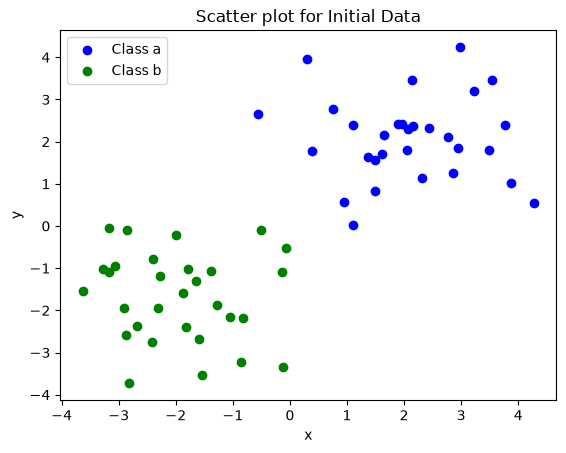

In [4]:
plt.scatter(class_a[:, 0], class_a[:, 1], color = 'b', label = "Class a")
plt.scatter(class_b[:, 0], class_b[:, 1], color = 'g', label = "Class b")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot for Initial Data")
plt.savefig("plots/KNN initial data.svg", bbox_inches="tight")
plt.savefig("plots/KNN initial data.jpg", bbox_inches="tight", dpi=300)
plt.legend()
plt.show()


In [5]:
# TODO: pick a query point and call knn_predict to classify it

k = 2

knn_predict(np.array([2, 2]), 
            X_train=X_train, 
            Y_train=y_train, 
            k=k
        )


np.int64(0)

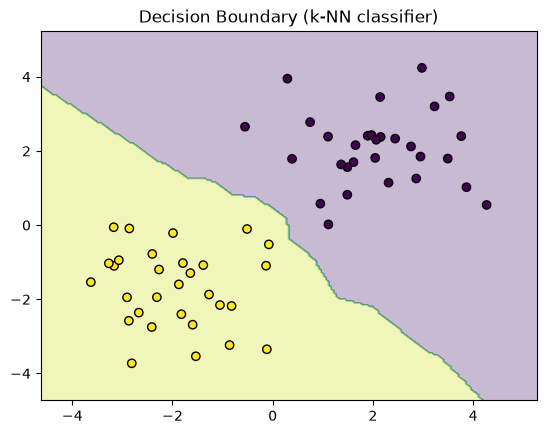

In [ ]:
# TODO: build a meshgrid over the training data's range, classify every grid point,
# and plot the decision boundary with contourf (don't forget to reshape predictions to xx.shape)

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

predictions = predict_grid(
    grid_points,
    X_train,
    y_train,
    k=k
).reshape(xx.shape)

fig, ax = plt.subplots()
ax.contourf(xx, yy, predictions, alpha=0.3)
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k")
ax.set_title("Decision Boundary (k-NN classifier)")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("plots/KNN decision boundary.svg", bbox_inches="tight")
plt.savefig("plots/KNN decision boundary.jpg", bbox_inches="tight", dpi=300)
plt.show()



## Part B: Gradient Descent

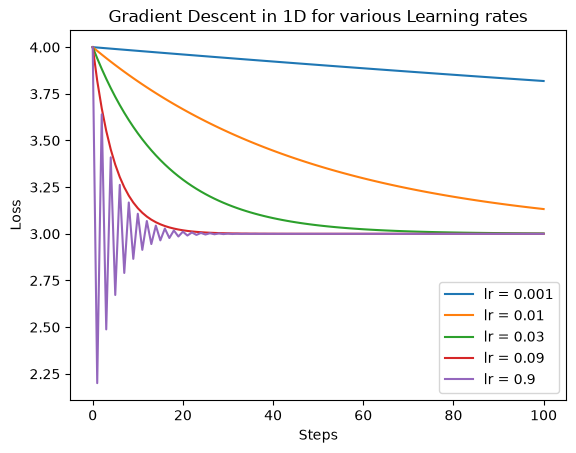

In [7]:
# TODO: run gradient_descent_1d with at least three learning rates and plot loss vs. iteration for each
# (include at least one learning rate that visibly diverges or oscillates)
start = 4
lr_list = [0.001, 0.01, 0.03, 0.09, 0.9]
steps = 100

for lr in lr_list:
    final_x, history = gradient_descent_1d(start, lr, steps)
    plt.plot(history, label = f"lr = {lr}")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Gradient Descent in 1D for various Learning rates")
plt.savefig("plots/gradient descent 1d.svg", bbox_inches="tight")
plt.savefig("plots/gradient descent 1d.jpg", bbox_inches="tight", dpi=300)
plt.legend()
plt.show()

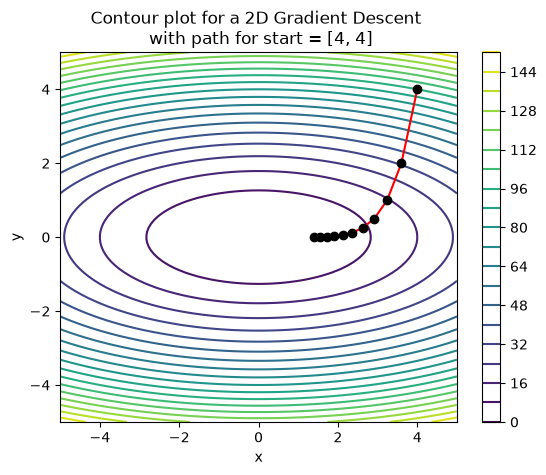

In [8]:
# TODO: run gradient_descent_2d and plot the path over a contour plot of f2

# Create a grid
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)


# parameters of the function
# rng = np.random.default_rng(42)

start = [4, 4] # rng.uniform(-4, 4, 2)

# Define a function
Z = f2(X, Y)
final_pt, path= gradient_descent_2d(start = start, lr = 0.05, steps = 10)
# Contour plot
plt.contour(X, Y, Z, levels=20)
plt.plot(
    path[:,0],
    path[:,1],
    color='red',            # line color
    marker='o',             # marker shape
    markerfacecolor='black',# fill color of marker
    markeredgecolor='black' # border color of marker
)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Contour plot for a 2D Gradient Descent \n with path for start = {start}")
plt.savefig("plots/gradient descent 2d.svg", bbox_inches="tight")
plt.savefig("plots/gradient descent 2d.jpg", bbox_inches="tight", dpi=300)
plt.show()



## Part C: PCA Via SVD

In [9]:
# TODO: generate a 2D dataset with an obvious principal direction (e.g. y = 2x + noise)

np.random.seed(42)
x = np.random.randn(200)
y = 2 * x + 0.5 * np.random.randn(len(x))
data = np.column_stack((x, y))



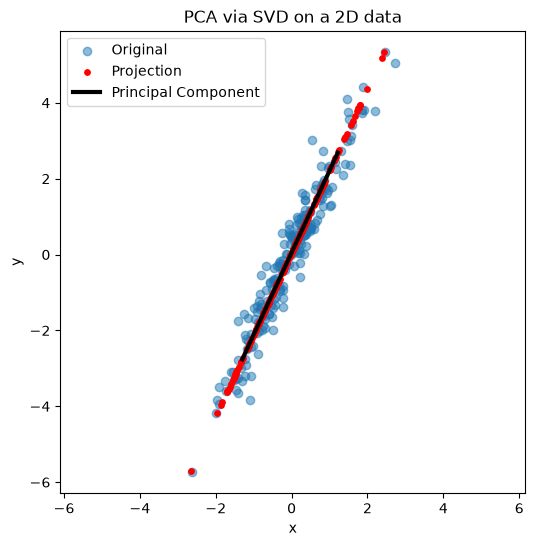

In [10]:
# TODO: call pca_via_svd, then plot the original (centered) data, the principal direction,
# and the projection together on one chart

projection, components = pca_via_svd(data, n_components=1)

# Reconstruct back to 2D
mean = np.mean(data, axis=0)
projection_2d = projection @ components + mean


principal_direction = components[0]

t = np.linspace(-3, 3, 100)

line = mean + np.outer(t, principal_direction)



plt.figure(figsize=(6,6))

plt.scatter(data[:,0], data[:,1], alpha=0.5, label="Original")
plt.scatter(projection_2d[:,0], projection_2d[:,1],
            color="red", s=15, label="Projection")

plt.plot(line[:,0], line[:,1],
         color="black", linewidth=3, label="Principal Component")

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("PCA via SVD on a 2D data")
plt.savefig("plots/PCA on 2d data.svg", bbox_inches="tight")
plt.savefig("plots/PCA on 2d data.jpg", bbox_inches="tight", dpi=300)
plt.legend()
plt.show()